In [1]:
import torch
import numpy as np
from tqdm import tqdm

import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
%config InlineBackend.figure_format = 'retina'
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] =  "\\usepackage{bm}"

from src.metrics.alignment.soft_match import SoftMatch
from src.metrics.alignment.partial_wasserstein import UnbalancedSoftMatch
from src.utils.regularization_search import compute_residuals_and_transport
from src.utils.synthesize import generate_factor_matrix, generate_sparsity_matrix, generate_random_normal_matrix, concat_noisy_neurons

In [2]:
n = 100
num_stimulus = 1000
num_linear_independent_factors = 50

In [3]:
# generate a common sparsity and factor matrix for all representations
sparsity_matrix = generate_sparsity_matrix(k=num_linear_independent_factors, n=n, sparsity=0.9)
factor_matrix = generate_factor_matrix(m=num_stimulus, k=num_linear_independent_factors)

# generate 3 random normal matrices
x1 = generate_random_normal_matrix(k=num_linear_independent_factors, n=n)
x2 = generate_random_normal_matrix(k=num_linear_independent_factors, n=n)
x3 = generate_random_normal_matrix(k=num_linear_independent_factors, n=n)

# generate Mi's
m1 = sparsity_matrix * x1
m2 = sparsity_matrix * x2
m3 = sparsity_matrix * x3

# final representations
x = factor_matrix @ m1
# y_a has 100 signal neurons
y_a = factor_matrix @ m2 

# y_b has 80 signal neurons
y_b = (factor_matrix @ m3)[..., 20:]

In [4]:
# now, we add 60 noisy neurons to y_a
y_a_noisy = concat_noisy_neurons(m=num_stimulus,
                                 neuron_signal=y_a,                                 
                                 num_noisy_neurons=60)

# and 20 noisy neurons to y_b
y_b_noisy = concat_noisy_neurons(m=num_stimulus,
                                 neuron_signal=y_b,                                 
                                 num_noisy_neurons=20)

In [5]:
# L-curve for y_a noisy
transport_costs, residuals, mreg = compute_residuals_and_transport(matrix1=y_a_noisy, matrix2=x, num_points=200)
ddy = np.gradient(np.gradient(transport_costs))
inflection_idx = np.argmax(np.abs(ddy)) + 1
inflection_mreg = mreg[inflection_idx]
inflection_cost = transport_costs[inflection_idx]
inflection_residual = residuals[inflection_idx]
metric = UnbalancedSoftMatch(mass_reg=inflection_mreg)
unsm_score = np.mean(np.array(metric.fit_kfold_score(torch.tensor(y_a_noisy), torch.tensor(x))))

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:13<00:00, 14.94it/s]


Inflection occurs at mreg value: 0.628
alignment score: 0.6401163958864944


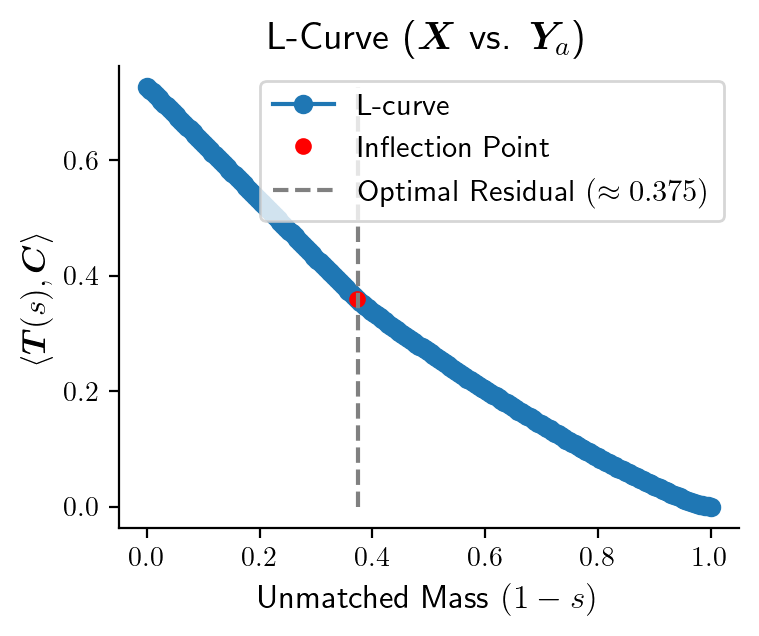

In [6]:
print(f"Inflection occurs at mreg value: {inflection_mreg.item():.3f}")
print(f'alignment score: {unsm_score}')
plt.figure(figsize=(4, 3))
plt.plot(residuals,
         transport_costs, 
         'o-', 
         label=r"L-curve")
plt.plot(inflection_residual,
         inflection_cost,
         'ro',
         markersize=5,
         label="Inflection Point")
plt.vlines(x=60/160,
           ymin=0, 
           ymax=max(transport_costs), 
           color='gray',
           linestyles='dashed', 
           label=r'Optimal Residual $(\approx 0.375)$')
plt.ylabel(r"$\langle \bm{T}(s), \bm{C}\rangle$", fontsize=12)
plt.xlabel(r"Unmatched Mass $(1-s)$", fontsize=12)
plt.title(r"L-Curve ($\bm{X}$ vs. $\bm{Y}_a$)", fontsize=14)

plt.legend(fontsize=11)
plt.grid(False)
sns.despine(trim=False)
#plt.savefig(f'./x-vs-ya-model-selection.png',
#            dpi=300,
#            bbox_inches='tight')
plt.show()

In [7]:
# the soft-matching score is unable to distinguish 2 models faithfully
soft_match = SoftMatch()
sm_score = np.mean(soft_match.fit_kfold_score(torch.tensor(y_a_noisy), torch.tensor(x)))
print(sm_score)

0.27149559942024154


In [8]:
# L-curve for y_b noisy
transport_costs, residuals, mreg = compute_residuals_and_transport(matrix1=y_b_noisy, 
                                                                   matrix2=x,
                                                                   num_points=200)
ddy = np.gradient(np.gradient(transport_costs))
inflection_idx = np.argmax(np.abs(ddy)) + 1
inflection_mreg = mreg[inflection_idx]
inflection_cost = transport_costs[inflection_idx]
inflection_residual = residuals[inflection_idx]

# align representations using optimal mreg
metric = UnbalancedSoftMatch(mass_reg=inflection_mreg)
unsm_score = np.mean(np.array(metric.fit_kfold_score(torch.tensor(y_b_noisy), torch.tensor(x))))

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:09<00:00, 20.20it/s]


Inflection occurs at mreg value: 0.693
alignment score: 0.6124273490462835


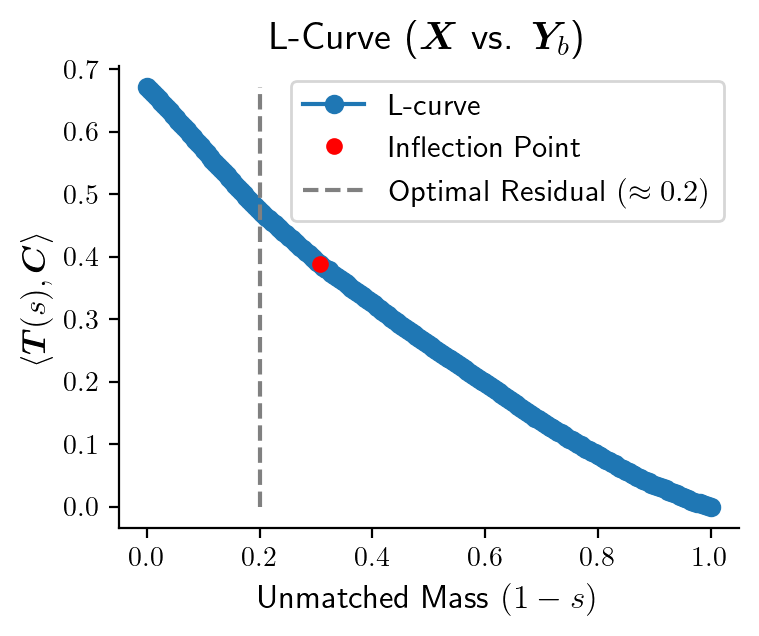

In [13]:
 print(f"Inflection occurs at mreg value: {inflection_mreg.item():.3f}")
print(f'alignment score: {unsm_score}')
plt.figure(figsize=(4, 3))
plt.plot(residuals, transport_costs, 'o-', label=r"L-curve")
plt.plot(1-inflection_mreg, inflection_cost, 'ro', markersize=5, label="Inflection Point")
plt.vlines(x=20/100,
           ymin=0, 
           ymax=max(transport_costs), 
           color='gray',
           linestyles='dashed', 
           label=r'Optimal Residual $(\approx 0.2)$')

plt.ylabel(r"$\langle \bm{T}(s), \bm{C}\rangle$", fontsize=12)
plt.xlabel(r"Unmatched Mass $(1-s)$", fontsize=12)
plt.title(r"L-Curve ($\bm{X}$ vs. $\bm{Y}_b$)", fontsize=14)

plt.legend(fontsize=11)
plt.grid(False)
sns.despine(trim=False)
#plt.savefig(f'./x-vs-yb-model-selection.png',
#            dpi=300,
#           bbox_inches='tight')
plt.show()